In [2]:
import pandas as pd

df = pd.read_csv('NovaMarket_datos_crudos.csv')
df.shape

(620, 14)

In [3]:
df.head()

,id_pedido,id_cliente,fecha_compra,canal,ciudad,codigo_postal,categoria_producto,producto,precio,unidades,edad_cliente,correo,nivel_satisfaccion,fecha_actualizacion_stock
0,P00383,C0276,2026-01-03,App,Bucaramanga,68001,Belleza,Camiseta,-1742611.0,4,-19,c0276gmail.com,alto,2026-07-01
1,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,1828583.0,2,23,c0167@hotmail.com,MEDIO,2026-07-01
2,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,1828583.0,2,23,c0167@hotmail.com,MEDIO,2026-07-01
3,P00450,C0128,07/09/2026,App,bucaramanga,68001,electronica,Set bloques,787178.0,6,69,c0128@hotmail.com,MEDIO,2026-07-15
4,P00449,C0304,2025-07-19,Tienda,Bogotá,8001,Belleza,Audífonos BT,357231.0,5,67,c0304@novamarket.co,Bajo,2026-05-20


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_pedido                  620 non-null    str    
 1   id_cliente                 620 non-null    str    
 2   fecha_compra               620 non-null    str    
 3   canal                      620 non-null    str    
 4   ciudad                     589 non-null    str    
 5   codigo_postal              620 non-null    int64  
 6   categoria_producto         620 non-null    str    
 7   producto                   620 non-null    str    
 8   precio                     599 non-null    float64
 9   unidades                   620 non-null    int64  
 10  edad_cliente               620 non-null    int64  
 11  correo                     516 non-null    str    
 12  nivel_satisfaccion         574 non-null    str    
 13  fecha_actualizacion_stock  620 non-null    str    
dtypes: fl

In [4]:
df.describe(include='all')

,id_pedido,id_cliente,fecha_compra,canal,ciudad,codigo_postal,categoria_producto,producto,precio,unidades,edad_cliente,correo,nivel_satisfaccion,fecha_actualizacion_stock
count,620,620,620,620,589,620.000000,620,620,5.990000e+02,620.000000,620.000000,516,574,620
unique,600,311,495,3,19,NaN,17,14,NaN,NaN,NaN,429,8,8
top,P00201,C0043,15/11/2027,Tienda,bucaramanga,NaN,Belleza,Perfume,NaN,NaN,NaN,c0012@hotmail.com,Alto,2026-07-15
freq,2,6,9,224,58,NaN,66,52,NaN,NaN,NaN,4,91,152
mean,NaN,NaN,NaN,NaN,NaN,31917.129032,NaN,NaN,4.888703e+06,188.682258,48.012903,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,30339.586863,NaN,NaN,4.292512e+07,1240.652475,28.668511,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,5001.000000,NaN,NaN,-2.448455e+06,-3.000000,-20.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,8001.000000,NaN,NaN,5.914020e+05,2.000000,31.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,13001.000000,NaN,NaN,1.178666e+06,3.000000,46.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,68001.000000,NaN,NaN,1.856670e+06,5.000000,63.000000,NaN,NaN,NaN



# Primeras impresiones
- ¿Cuantos registros hay?
Hay 620 registros
- ¿Cuantas variables hay?
Hay 14 variables
- ¿Que tipos de variables hay?
Strings, int y float
- ¿qué problemas saltan a la vista (vacíos, formatos raros, posibles duplicados)?
Hay pedidos repetidos
- Clasifica al menos 5 variables por su tipo y nivel de medición:
1. id_pedido: String - Ordinal
2. id_cliente: String - Nominal
3. ciudad: String - Nominal
4. producto: str - Nominal
5. precio: float64 - 

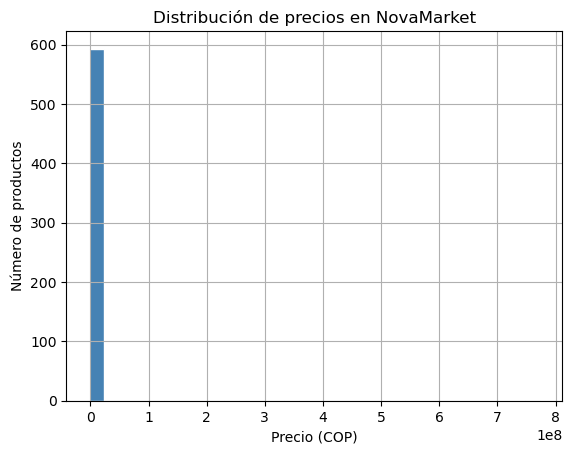

In [5]:
import matplotlib.pyplot as plt

# Histograma de la columna precio del dataset NovaMarket
df['precio'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de precios en NovaMarket')
plt.xlabel('Precio (COP)')
plt.ylabel('Número de productos')
plt.show()

In [7]:
df.describe()


,codigo_postal,precio,unidades,edad_cliente
count,620.000000,5.990000e+02,620.000000,620.000000
mean,31917.129032,4.888703e+06,188.682258,48.012903
std,30339.586863,4.292512e+07,1240.652475,28.668511
min,5001.000000,-2.448455e+06,-3.000000,-20.000000
25%,8001.000000,5.914020e+05,2.000000,31.000000
50%,13001.000000,1.178666e+06,3.000000,46.000000
75%,68001.000000,1.856670e+06,5.000000,63.000000
max,76001.000000,7.730038e+08,9999.000000,200.000000


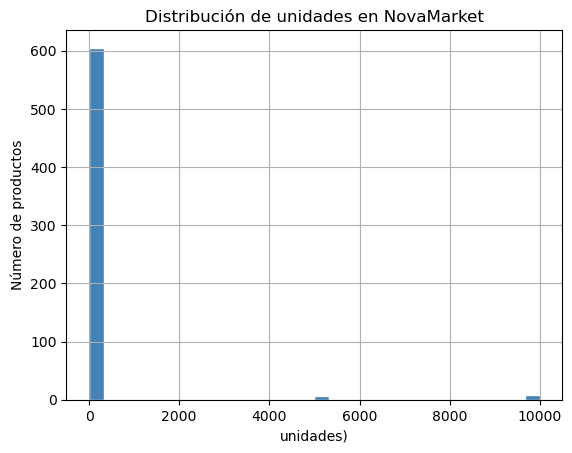

In [10]:
df['unidades'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de unidades en NovaMarket')
plt.xlabel('unidades)')
plt.ylabel('Número de productos')
plt.show()

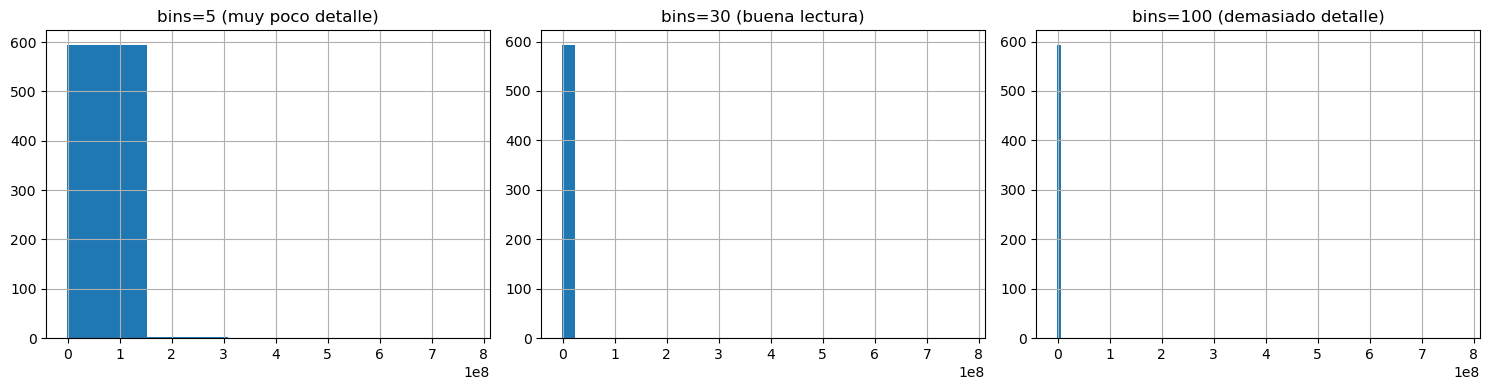

In [6]:
# Comparar el mismo dato con distinto número de bins
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['precio'].hist(bins=5,   ax=axes[0]); axes[0].set_title('bins=5 (muy poco detalle)')
df['precio'].hist(bins=30,  ax=axes[1]); axes[1].set_title('bins=30 (buena lectura)')
df['precio'].hist(bins=100, ax=axes[2]); axes[2].set_title('bins=100 (demasiado detalle)')

plt.tight_layout()
plt.show()

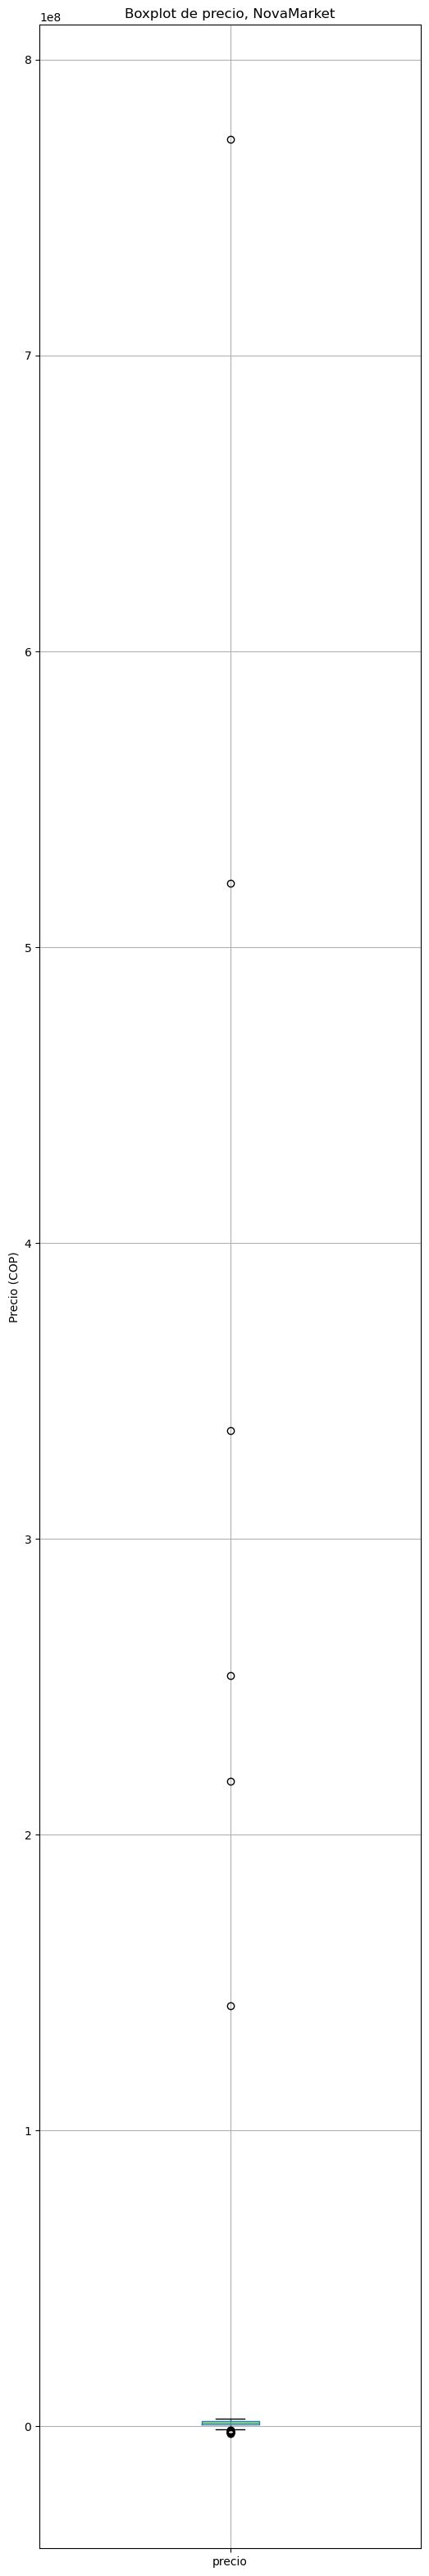

In [ ]:
import matplotlib.pyplot as plt

# Boxplot de una sola columna del dataset NovaMarket
df.boxplot(column='precio', vert=True, figsize=(6,40))
plt.title('Boxplot de precio, NovaMarket')
plt.ylabel('Precio (COP)')
plt.show()

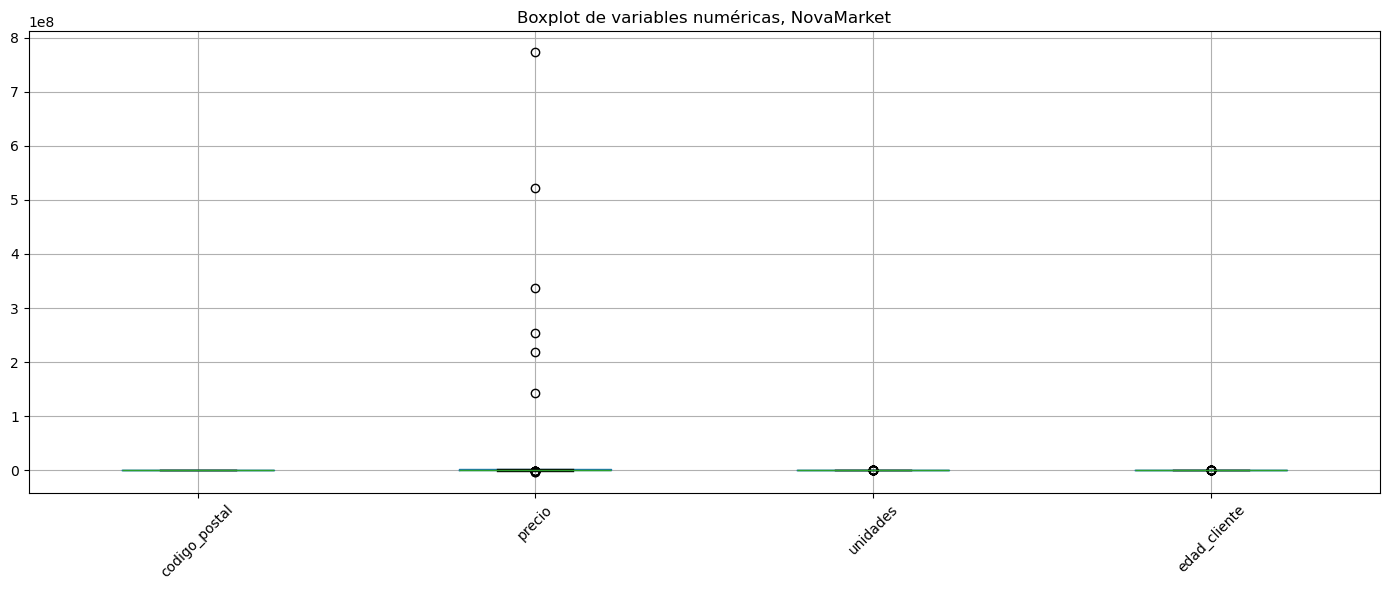

In [12]:
# Boxplot de todas las variables numéricas a la vez
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
df[columnas_numericas].boxplot(figsize=(14, 6), rot=45)
plt.title('Boxplot de variables numéricas, NovaMarket')
plt.tight_layout()
plt.show()

In [14]:
# Método 1: comparar media y mediana (rápido, sin fórmulas)
media = df['precio'].mean()
mediana = df['precio'].median()

if media > mediana:
    print(f"Sesgo positivo (a la derecha). Media: {media:.2f} | Mediana: {mediana:.2f}")
elif media < mediana:
    print(f"Sesgo negativo (a la izquierda). Media: {media:.2f} | Mediana: {mediana:.2f}")
else:
    print("Distribución aproximadamente simétrica.")

# Método 2: coeficiente de asimetría (skewness), un solo número
print(f"Skewness de precio: {df['precio'].skew():.2f}")


Sesgo positivo (a la derecha). Media: 4888703.29 | Mediana: 1178666.00
Skewness de precio: 13.90


In [15]:
# Comparación con otras columnas del dataset:
df[['precio', 'unidades', 'edad_cliente']].skew()
# precio          13.89 → sesgo fuerte a la derecha
# unidades        7.069 → sesgo fuerte a la derecha
# edad_cliente    2.08 → mejor pero a la derecha

precio          13.899942
unidades         7.069053
edad_cliente     2.082409
dtype: float64